# Modelling Rainfall in Wädenswil

This notebook explores different optimization algorithms for the purpose of modelling rainfall in Wädenswil (CH). The dataset used can be found under the following link:
https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/wae/ogd-smn_wae_d_historical.csv

---

## PROBLEM STATEMENT

The goal of this project is to predict daily rainfall (`precip_0utc_d`) from meteorological parameters such as air temperature, soil temperature, wind or vapor pressure.

In order to try and minimize the complexity of the optimization problem and investigate the influence of dimension reduction on typical optimization algorithms we consider two optimization problems:

1. **Feature selection**: find a subset of input features that yields good predictive performance  
2. **Parameter optimization**: find model parameters that minimize prediction error for a fixed feature subset

Feature selection is performed using Ant Colony Optimization (ACO).  
Model parameters are optimized using Gradient Descent (GD), Simulated Annealing (SA), and a Genetic Algorithm (GA).

Finally the performance of the fixed feature subset model is compared to a full model that includes all features. 

---

## MATHEMATICAL FORMULATION

For a fixed feature subset $S$, we use a linear regression model

$$
\hat{y}_i = w_0 + \sum_{j \in S} w_j x_{ij}
$$

where:
- $x_{ij}$ is feature $j$ for sample $i$
- $w_j$ are model parameters
- $\hat{y}_i$ is the predicted precipitation

The parameter optimization problem is

$$
\min_{w} \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

where $y_i$ is the observed precipitation.

The feature selection problem is

$$
\min_{S \subseteq \mathcal{F}} \; \text{MSE}_{val}(S)
$$

where $\mathcal{F}$ is the full feature set and $\text{MSE}_{val}(S)$ is the validation error obtained after fitting the model on subset $S$.

---

## IMPLEMENTATION

Additionally to the base features from the dataset the following metrics were derived:
- Precipitation Lag (1-3): Encodes if there was rainfall in the prior days
- Seasonal Features: Datetime encoded as sine and cosine, year and month

#### List of Features

| Nr. | Feature | Description |
|---:|---|---|
| 1 | `temp2m_mean_d` | Daily mean air temperature at 2 m above ground |
| 2 | `temp2m_max_d` | Daily maximum air temperature at 2 m above ground |
| 3 | `temp2m_min_d` | Daily minimum air temperature at 2 m above ground |
| 4 | `temp5cm_mean_d` | Daily mean near-surface temperature at 5 cm |
| 5 | `temp5cm_max_d` | Daily maximum near-surface temperature at 5 cm |
| 6 | `temp5cm_min_d` | Daily minimum near-surface temperature at 5 cm |
| 7 | `rh2m_mean_d` | Daily mean relative humidity at 2 m above ground |
| 8 | `vapor_pressure_d` | Daily mean vapor pressure, describing atmospheric moisture content |
| 9 | `wind_ms_mean_d` | Daily mean wind speed in m/s |
| 10 | `gust_ms_max_d` | Daily maximum wind gust in m/s |
| 11 | `wind_kmh_mean_d` | Daily mean wind speed in km/h |
| 12 | `gust_kmh_max_d` | Daily maximum wind gust in km/h |
| 13 | `wind_dir_mean_d` | Daily mean wind direction |
| 14 | `heating_degree_days_d` | Daily heating degree days |
| 15 | `heating_degree_days_atd12_d` | Daily heating degree days relative to a 12°C threshold |
| 16 | `water_balance_d` | Daily water balance |
| 17 | `soil_temp_5cm_mean_d` | Daily mean soil temperature at 5 cm depth |
| 18 | `soil_temp_10cm_mean_d` | Daily mean soil temperature at 10 cm depth |
| 19 | `soil_temp_20cm_mean_d` | Daily mean soil temperature at 20 cm depth |
| 20 | `doy_sin` | Sine-transformed day-of-year feature to encode annual seasonality |
| 21 | `doy_cos` | Cosine-transformed day-of-year feature to encode annual seasonality |
| 22 | `year` | Calendar year |
| 23 | `month` | Calendar month |
| 24 | `precip_lag1` | Precipitation of the previous day |
| 25 | `precip_lag2` | Precipitation two days before |
| 26 | `precip_lag3` | Precipitation three days before |

The implemented pipeline is structured as follows:
#### 1. Feature Selection with ACO 
Each ant constructs a subset of features, which is evaluated using a linear regression model.  
Feature subsets that lead to lower prediction error receive stronger pheromone updates, increasing their probability of being selected in future iterations.


#### 2. Parameter Optimization — GD, SA, GA

For a fixed feature subset, we optimize the model parameters using three different approaches:

- **Gradient Descent (GD):**  
  A deterministic, gradient-based method that efficiently optimizes smooth objective functions.

- **Simulated Annealing (SA):**  
  A stochastic optimization method that explores the search space by occasionally accepting worse solutions to escape local minima.

- **Genetic Algorithm (GA):**  
  A population-based evolutionary algorithm that evolves candidate solutions using selection, crossover, and mutation.


#### 3. Model Evaluation and Comparison

All methods are evaluated on the same dataset using:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² score
- Runtime

The optimized model using only the feature subset proposed by ACO is then compared to a full model that uses all features. Thereby we can further compare the algorithms by the means of dimensionality and redundancy.

---

## Imports


In [79]:
import io
import matplotlib.pyplot as plt
import ssl
import urllib.request  
import numpy as np
import pandas as pd
import time

from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression


## Data Import and Preparation

In [80]:
station_url = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/wae/ogd-smn_wae_d_historical.csv"

ctx = ssl.create_default_context()

raw_text = urllib.request.urlopen(station_url, context=ctx).read().decode("utf-8")

try:
    station_df = pd.read_csv(io.StringIO(raw_text), sep=None, engine="python")
except Exception:
    station_df = pd.read_csv(io.StringIO(raw_text), sep=";")

station_df.head()


,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
0,WAE,01.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WAE,02.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,WAE,03.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,WAE,04.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,WAE,05.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
rename_dict = {
    "tre200d0": "temp2m_mean_d",
    "tre200dx": "temp2m_max_d",
    "tre200dn": "temp2m_min_d",
    "tre005d0": "temp5cm_mean_d",
    "tre005dx": "temp5cm_max_d",
    "tre005dn": "temp5cm_min_d",
    "ure200d0": "rh2m_mean_d",
    "prestad0": "atm_pressure_d",
    "pp0qffd0": "sealevel_pressure_d",
    "sre000d0": "sunshine_duration_d",
    "gre000d0": "global_radiation_d",
    "pva200d0": "vapor_pressure_d",
    "fkl010d0": "wind_ms_mean_d",
    "fkl010d1": "gust_ms_max_d",
    "wcc006d0": "foehn_idx_d",
    "rka150d0": "precip_0utc_d",
    "dkl010d0": "wind_dir_mean_d",
    "xno000d0": "heating_degree_days_d",
    "tso005d0": "soil_temp_5cm_mean_d",
    "tso010d0": "soil_temp_10cm_mean_d",
    "tso020d0": "soil_temp_20cm_mean_d",
}

base_cols = ["station_abbr", "reference_timestamp"]
value_cols = [c for c in rename_dict if c in station_df.columns]

df = station_df[base_cols + value_cols].copy()
df["reference_timestamp"] = pd.to_datetime(df["reference_timestamp"], dayfirst=True, errors="coerce")
df = df.rename(columns=rename_dict)

# Keep only rows with valid station/date/target for now
df = df.dropna(subset=["station_abbr", "reference_timestamp", "precip_0utc_d"]).reset_index(drop=True)

# Sort first
df = df.sort_values(["station_abbr", "reference_timestamp"]).reset_index(drop=True)
df.head()

,station_abbr,reference_timestamp,temp2m_mean_d,temp2m_max_d,temp2m_min_d,temp5cm_mean_d,temp5cm_max_d,temp5cm_min_d,rh2m_mean_d,atm_pressure_d,...,vapor_pressure_d,wind_ms_mean_d,gust_ms_max_d,foehn_idx_d,precip_0utc_d,wind_dir_mean_d,heating_degree_days_d,soil_temp_5cm_mean_d,soil_temp_10cm_mean_d,soil_temp_20cm_mean_d
0,WAE,1981-01-01,2.7,5.2,-3.2,1.4,4.6,-6.0,66.4,NaN,...,4.9,4.9,14.0,NaN,1.2,259.0,17.3,0.2,0.5,1.0
1,WAE,1981-01-02,1.5,3.5,0.2,1.0,2.8,-0.2,80.5,NaN,...,5.5,3.3,13.3,NaN,4.4,252.0,18.5,0.2,0.6,1.0
2,WAE,1981-01-03,6.2,9.3,2.4,4.9,8.3,0.3,62.8,NaN,...,5.9,6.0,22.6,NaN,11.2,261.0,13.8,1.0,0.9,1.1
3,WAE,1981-01-04,2.6,6.2,-2.2,1.8,4.9,-2.0,84.1,NaN,...,6.3,3.9,21.4,NaN,26.4,260.0,17.4,1.8,1.8,1.8
4,WAE,1981-01-05,-0.5,1.3,-1.8,-0.8,1.8,-2.3,73.2,NaN,...,4.3,6.7,16.8,NaN,2.0,250.0,20.5,1.0,1.2,1.5


In [82]:
TARGET_COL = "precip_0utc_d"
STATION_COL = "station_abbr" 
DATE_COL = "reference_timestamp"

TEST_SIZE = 0.15
VAL_SIZE  = 0.15
RANDOM_SEED = 42

# Time aware split
TIME_AWARE_SPLIT = True if DATE_COL else False

In [83]:
def add_time_features(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    """
    Creates numeric time features in the form of sine and cosine encodings.
    Seasonality is encoded as a cycle.
    """
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    # day-of-year cyclic encoding
    doy = d[date_col].dt.dayofyear.astype(int)
    d["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    d["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    # year and month are kept as numeric features additionally
    d["year"] = d[date_col].dt.year.astype(int)
    d["month"] = d[date_col].dt.month.astype(int)

    return d



In [84]:
def enforce_daily_grid_and_add_target_lags(
    df: pd.DataFrame,
    station_col: str,
    date_col: str,
    target_col: str,
    lags: List[int]
) -> pd.DataFrame:
    """
    Reindex each station to a complete daily calendar so that shift(L)
    means exactly L calendar days earlier.
    """
    out_parts = []

    for station, g in df.groupby(station_col, sort=False):
        g = g.sort_values(date_col).copy()

        full_dates = pd.date_range(
            start=g[date_col].min(),
            end=g[date_col].max(),
            freq="D"
        )

        g = g.set_index(date_col).reindex(full_dates).rename_axis(date_col).reset_index()
        g[station_col] = station

        for L in lags:
            g[f"precip_lag{L}"] = g[target_col].shift(L)

        out_parts.append(g)

    out = pd.concat(out_parts, ignore_index=True)
    out = out.sort_values([station_col, date_col]).reset_index(drop=True)
    return out

In [85]:
# Sanity checks

missing = [c for c in [TARGET_COL, STATION_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

if DATE_COL is not None and DATE_COL not in df.columns:
    raise ValueError(f"DATE_COL='{DATE_COL}' not found in df. Set DATE_COL=None or correct the name.")

if len(CANDIDATE_FEATURES) == 0:
    raise ValueError("No numeric candidate features found after exclusions.")

df[[TARGET_COL] + CANDIDATE_FEATURES[:10]].head()

,precip_0utc_d,temp2m_mean_d,temp2m_max_d,temp2m_min_d,temp5cm_mean_d,temp5cm_max_d,temp5cm_min_d,rh2m_mean_d,atm_pressure_d,sealevel_pressure_d,sunshine_duration_d
0,1.2,2.7,5.2,-3.2,1.4,4.6,-6.0,66.4,NaN,NaN,1.0
1,4.4,1.5,3.5,0.2,1.0,2.8,-0.2,80.5,NaN,NaN,0.0
2,11.2,6.2,9.3,2.4,4.9,8.3,0.3,62.8,NaN,NaN,0.0
3,26.4,2.6,6.2,-2.2,1.8,4.9,-2.0,84.1,NaN,NaN,4.0
4,2.0,-0.5,1.3,-1.8,-0.8,1.8,-2.3,73.2,NaN,NaN,50.0


In [86]:
if DATE_COL is not None:
    df = add_time_features(df, DATE_COL)

# Add true calendar-day precipitation lags
LAGS = [1, 2, 3]
df = enforce_daily_grid_and_add_target_lags(
    df=df,
    station_col=STATION_COL,
    date_col=DATE_COL,
    target_col=TARGET_COL,
    lags=LAGS
)

excluded = {TARGET_COL, STATION_COL}
if DATE_COL is not None:
    excluded.add(DATE_COL)

CANDIDATE_FEATURES = [c for c in df.columns if c not in excluded]
CANDIDATE_FEATURES = [c for c in CANDIDATE_FEATURES if pd.api.types.is_numeric_dtype(df[c])]

print("Num candidate features:", len(CANDIDATE_FEATURES))
print(CANDIDATE_FEATURES)

Num candidate features: 27
['temp2m_mean_d', 'temp2m_max_d', 'temp2m_min_d', 'temp5cm_mean_d', 'temp5cm_max_d', 'temp5cm_min_d', 'rh2m_mean_d', 'atm_pressure_d', 'sealevel_pressure_d', 'sunshine_duration_d', 'global_radiation_d', 'vapor_pressure_d', 'wind_ms_mean_d', 'gust_ms_max_d', 'foehn_idx_d', 'wind_dir_mean_d', 'heating_degree_days_d', 'soil_temp_5cm_mean_d', 'soil_temp_10cm_mean_d', 'soil_temp_20cm_mean_d', 'doy_sin', 'doy_cos', 'year', 'month', 'precip_lag1', 'precip_lag2', 'precip_lag3']


## INSPECT DATA

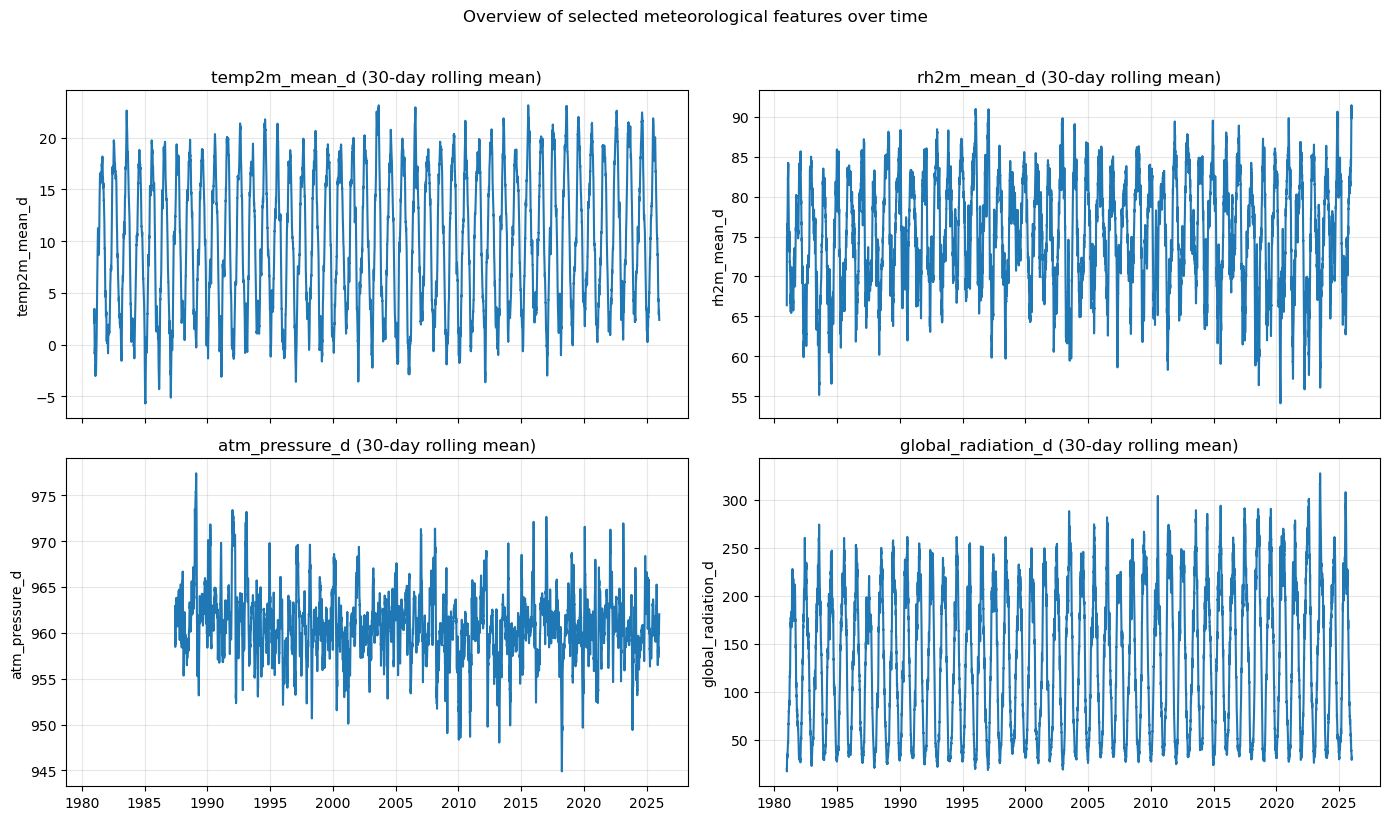

In [87]:
# Plot some features for overview
plot_features = [
    "temp2m_mean_d",
    "rh2m_mean_d",
    "atm_pressure_d",
    "global_radiation_d",
]

plot_df = df[[DATE_COL] + plot_features].copy().sort_values(DATE_COL)
plot_df[DATE_COL] = pd.to_datetime(plot_df[DATE_COL])

roll_days = 30

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.ravel()

for ax, feat in zip(axes, plot_features):
    ax.plot(
        plot_df[DATE_COL],
        plot_df[feat].rolling(roll_days, min_periods=1).mean()
    )
    ax.set_title(f"{feat} ({roll_days}-day rolling mean)")
    ax.set_ylabel(feat)
    ax.grid(alpha=0.3)

plt.suptitle("Overview of selected meteorological features over time", y=1.02)
plt.tight_layout()
plt.show()

In [88]:
# Inspect how much data is actually used and how much is dropped

n_raw = len(station_df)

df_selected = station_df[base_cols + value_cols].copy()
df_selected[DATE_COL] = pd.to_datetime(df_selected[DATE_COL], dayfirst=True, errors="coerce")
df_selected = df_selected.rename(columns=rename_dict)
n_selected = len(df_selected)

df_base = df_selected.dropna(subset=[STATION_COL, DATE_COL, TARGET_COL]).reset_index(drop=True)
df_base = df_base.sort_values([STATION_COL, DATE_COL]).reset_index(drop=True)
n_after_base_filter = len(df_base)

first_raw_ts = df_base[DATE_COL].min()
last_raw_ts = df_base[DATE_COL].max()
raw_span_days = (last_raw_ts - first_raw_ts).days

df_pipeline = df_base.copy()
if DATE_COL is not None:
    df_pipeline = add_time_features(df_pipeline, DATE_COL)

LAGS = [1, 2, 3]
df_pipeline = enforce_daily_grid_and_add_target_lags(
    df=df_pipeline,
    station_col=STATION_COL,
    date_col=DATE_COL,
    target_col=TARGET_COL,
    lags=LAGS
)
n_after_daily_grid = len(df_pipeline)

first_grid_ts = df_pipeline[DATE_COL].min()
last_grid_ts = df_pipeline[DATE_COL].max()
grid_span_days = (last_grid_ts - first_grid_ts).days

excluded_tmp = {TARGET_COL, STATION_COL}
if DATE_COL is not None:
    excluded_tmp.add(DATE_COL)

candidate_features_tmp = [c for c in df_pipeline.columns if c not in excluded_tmp]
candidate_features_tmp = [
    c for c in candidate_features_tmp
    if pd.api.types.is_numeric_dtype(df_pipeline[c])
]

used_cols = candidate_features_tmp + [TARGET_COL, STATION_COL, DATE_COL]
df_final_used = df_pipeline.dropna(
    subset=[c for c in used_cols if c is not None]
).reset_index(drop=True)

n_final_used = len(df_final_used)

first_used_ts = df_final_used[DATE_COL].min()
last_used_ts = df_final_used[DATE_COL].max()
used_span_days = (last_used_ts - first_used_ts).days

n_train = int(np.floor(0.60 * n_final_used))
n_sel   = int(np.floor(0.15 * n_final_used))
n_tune  = int(np.floor(0.10 * n_final_used))
n_test  = n_final_used - n_train - n_sel - n_tune

usage_summary = pd.DataFrame({
    "stage": [
        "Raw downloaded rows",
        "After selecting/renaming columns",
        "After base filter (valid station/date/target)",
        "After enforcing full daily grid",
        "Final rows usable for modeling",
        "Train rows",
        "Selection rows",
        "Tuning rows",
        "Test rows",
    ],
    "n_rows": [
        n_raw,
        n_selected,
        n_after_base_filter,
        n_after_daily_grid,
        n_final_used,
        n_train,
        n_sel,
        n_tune,
        n_test,
    ]
})

usage_summary["pct_of_raw"] = 100 * usage_summary["n_rows"] / n_raw

timeline_summary = pd.DataFrame({
    "timeline_stage": [
        "Observed data before daily grid",
        "Daily grid timeline",
        "Final usable modeling rows",
    ],
    "first_timestamp": [
        first_raw_ts,
        first_grid_ts,
        first_used_ts,
    ],
    "last_timestamp": [
        last_raw_ts,
        last_grid_ts,
        last_used_ts,
    ],
    "span_days": [
        raw_span_days,
        grid_span_days,
        used_span_days,
    ],
})

print("Usage summary:")
display(usage_summary)

print("\nTimeline summary:")
display(timeline_summary)

Usage summary:


,stage,n_rows,pct_of_raw
0,Raw downloaded rows,23741,100.000000
1,After selecting/renaming columns,23741,100.000000
2,After base filter (valid station/date/target),16415,69.141991
3,After enforcing full daily grid,16436,69.230445
4,Final rows usable for modeling,4924,20.740491
5,Train rows,2954,12.442610
6,Selection rows,738,3.108546
7,Tuning rows,492,2.072364
8,Test rows,740,3.116971



Timeline summary:


,timeline_stage,first_timestamp,last_timestamp,span_days
0,Observed data before daily grid,1981-01-01,2025-12-31,16435
1,Daily grid timeline,1981-01-01,2025-12-31,16435
2,Final usable modeling rows,2012-03-05,2025-12-31,5049


## Split Preparation 

We create a 4-way split for training, validation of the subset selection with ACO, tuning validation for each model and testing.

In [89]:
def make_time_splits_4way(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: List[str],
    station_col: str,
    date_col: str,
    train_frac: float = 0.60,
    sel_frac: float = 0.15,
    tune_frac: float = 0.10,
    test_frac: float = 0.15,
):
    assert abs(train_frac + sel_frac + tune_frac + test_frac - 1.0) < 1e-9

    d = df.copy()
    used_cols = feature_cols + [target_col, station_col, date_col]
    d = d.dropna(subset=[c for c in used_cols if c is not None]).reset_index(drop=True)
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values([station_col, date_col]).reset_index(drop=True)

    n = len(d)
    n_train = int(np.floor(train_frac * n))
    n_sel   = int(np.floor(sel_frac * n))
    n_tune  = int(np.floor(tune_frac * n))
    n_test  = n - n_train - n_sel - n_tune

    train_df = d.iloc[:n_train]
    sel_df   = d.iloc[n_train:n_train + n_sel]
    tune_df  = d.iloc[n_train + n_sel:n_train + n_sel + n_tune]
    test_df  = d.iloc[n_train + n_sel + n_tune:]

    X_train = train_df[feature_cols].to_numpy(dtype=float)
    y_train = train_df[target_col].to_numpy(dtype=float)

    X_sel = sel_df[feature_cols].to_numpy(dtype=float)
    y_sel = sel_df[target_col].to_numpy(dtype=float)

    X_tune = tune_df[feature_cols].to_numpy(dtype=float)
    y_tune = tune_df[target_col].to_numpy(dtype=float)

    X_test = test_df[feature_cols].to_numpy(dtype=float)
    y_test = test_df[target_col].to_numpy(dtype=float)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_sel_s   = scaler.transform(X_sel)
    X_tune_s  = scaler.transform(X_tune)
    X_test_s  = scaler.transform(X_test)

    return (X_train_s, y_train), (X_sel_s, y_sel), (X_tune_s, y_tune), (X_test_s, y_test), scaler
  

(X_train, y_train), (X_sel, y_sel), (X_tune, y_tune), (X_test, y_test), scaler = make_time_splits_4way(
    df=df,
    target_col=TARGET_COL,
    feature_cols=CANDIDATE_FEATURES,
    station_col=STATION_COL,
    date_col=DATE_COL,
    train_frac=0.60,
    sel_frac=0.15,
    tune_frac=0.10,
    test_frac=0.15,
)

print("Shapes:", X_train.shape, X_sel.shape, X_tune.shape, X_test.shape)

Shapes: (2954, 27) (738, 27) (492, 27) (740, 27)


## Define Helper Functions

In [90]:
def add_bias(X: np.ndarray) -> np.ndarray:
    return np.hstack([np.ones((X.shape[0], 1)), X])

def mse_loss(Xb: np.ndarray, y: np.ndarray, w: np.ndarray, l2: float = 0.0) -> float:
    preds = Xb @ w
    mse = np.mean((preds - y) ** 2)
    if l2 > 0:
        mse += l2 * np.sum(w[1:] ** 2)
    return float(mse)

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

## Define Optimization Algorithms


In [91]:
# Gradient Descent (GD)

@dataclass
class GDConfig:
    lr: float = 0.05
    steps: int = 2000
    l2: float = 0.0
    tol: float = 1e-9

def fit_gd(X: np.ndarray, y: np.ndarray, cfg: GDConfig) -> Tuple[np.ndarray, List[float]]:
    Xb = add_bias(X)
    n, d = Xb.shape
    w = np.zeros(d, dtype=float)

    history = []
    prev = np.inf

    for _ in range(cfg.steps):
        preds = Xb @ w
        err = preds - y
        grad = (2.0 / n) * (Xb.T @ err)

        if cfg.l2 > 0:
            reg = np.zeros_like(w)
            reg[1:] = 2 * cfg.l2 * w[1:]
            grad += reg

        w -= cfg.lr * grad

        preds_new = Xb @ w
        err_new = preds_new - y
        loss = np.mean(err_new ** 2)
        if cfg.l2 > 0:
            loss += cfg.l2 * np.sum(w[1:] ** 2)

        history.append(float(loss))

        if abs(prev - loss) < cfg.tol:
            break
        prev = loss

    return w, history

In [92]:
# Simulated Annealing (SA)

@dataclass
class SAConfig:
    steps: int = 4000
    T0: float = 1.0
    alpha: float = 0.995
    step_sigma: float = 0.05
    l2: float = 0.0
    seed: int = 42

def fit_sa(X: np.ndarray, y: np.ndarray, cfg: SAConfig) -> Tuple[np.ndarray, List[float]]:
    rng = np.random.default_rng(cfg.seed)
    Xb = add_bias(X)
    d = Xb.shape[1]

    w = rng.normal(0, 0.1, size=d)
    best_w = w.copy()

    cur = mse_loss(Xb, y, w, l2=cfg.l2)
    best = cur

    T = cfg.T0
    history = [cur]

    for _ in range(cfg.steps):
        w_new = w + rng.normal(0, cfg.step_sigma, size=d)
        new = mse_loss(Xb, y, w_new, l2=cfg.l2)

        delta = new - cur
        if delta <= 0 or rng.random() < np.exp(-delta / max(T, 1e-12)):
            w = w_new
            cur = new
            if cur < best:
                best = cur
                best_w = w.copy()

        history.append(cur)
        T *= cfg.alpha

    return best_w, history

In [93]:
# Genetic Algorithm (GA)

@dataclass
class GAConfig:
    pop_size: int = 60
    generations: int = 120
    elite: int = 4
    tournament_k: int = 3
    crossover_rate: float = 0.9
    mutation_rate: float = 0.2
    mutation_sigma: float = 0.05
    init_sigma: float = 0.3
    l2: float = 0.0
    seed: int = 42

def tournament_select(rng, fitness: np.ndarray, k: int) -> int:
    idx = rng.integers(0, len(fitness), size=k)
    return idx[np.argmax(fitness[idx])]

def blend_crossover(rng, a: np.ndarray, b: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    alpha = rng.random()
    c1 = alpha * a + (1 - alpha) * b
    c2 = (1 - alpha) * a + alpha * b
    return c1, c2

def fit_ga(X: np.ndarray, y: np.ndarray, cfg: GAConfig) -> Tuple[np.ndarray, List[float]]:
    rng = np.random.default_rng(cfg.seed)
    Xb = add_bias(X)
    d = Xb.shape[1]

    pop = rng.normal(0, cfg.init_sigma, size=(cfg.pop_size, d))

    def fitness_of(w: np.ndarray) -> float:
        return -mse_loss(Xb, y, w, l2=cfg.l2)

    history = []
    best_w = None
    best_loss = np.inf

    for _ in range(cfg.generations):
        fit = np.array([fitness_of(ind) for ind in pop], dtype=float)
        losses = -fit

        gbest_idx = int(np.argmin(losses))
        if float(losses[gbest_idx]) < best_loss:
            best_loss = float(losses[gbest_idx])
            best_w = pop[gbest_idx].copy()

        history.append(best_loss)

        elite_idx = np.argsort(losses)[:cfg.elite]
        new_pop = [pop[i].copy() for i in elite_idx]

        while len(new_pop) < cfg.pop_size:
            p1 = pop[tournament_select(rng, fit, cfg.tournament_k)]
            p2 = pop[tournament_select(rng, fit, cfg.tournament_k)]

            c1, c2 = p1.copy(), p2.copy()
            if rng.random() < cfg.crossover_rate:
                c1, c2 = blend_crossover(rng, p1, p2)

            if rng.random() < cfg.mutation_rate:
                c1 += rng.normal(0, cfg.mutation_sigma, size=d)
            if rng.random() < cfg.mutation_rate:
                c2 += rng.normal(0, cfg.mutation_sigma, size=d)

            new_pop.append(c1)
            if len(new_pop) < cfg.pop_size:
                new_pop.append(c2)

        pop = np.vstack(new_pop)

    return best_w, history

In [94]:
# Ant Colony Optimization (ACO) for FEATURE selection with GD evaluation

@dataclass
class ACOConfig:
    n_ants: int = 50
    n_iters: int = 30
    evaporation: float = 0.2   # rho
    q: float = 1.0             # deposit scaling
    top_k: int = 10            # reinforce from best k ants
    subset_min: int = 2
    subset_max: int = 10
    seed: int = 42

def sample_subset(rng, pheromone: np.ndarray, subset_size: int) -> np.ndarray:
    p = pheromone / pheromone.sum()
    return rng.choice(len(pheromone), size=subset_size, replace=False, p=p)

def evaluate_subset_with_lr(
    X_train_full: np.ndarray,
    y_train: np.ndarray,
    X_val_full: np.ndarray,
    y_val: np.ndarray,
    idx: np.ndarray,
) -> float:
    Xtr = X_train_full[:, idx]
    Xva = X_val_full[:, idx]

    model = LinearRegression()
    model.fit(Xtr, y_train)
    preds = model.predict(Xva)

    return float(mean_squared_error(y_val, preds))

def aco_feature_selection(
    X_train_full: np.ndarray, y_train: np.ndarray,
    X_val_full: np.ndarray, y_val: np.ndarray,
    feature_names: List[str],
    aco_cfg: ACOConfig
) -> Dict:
    rng = np.random.default_rng(aco_cfg.seed)
    n_features = len(feature_names)

    pheromone = np.ones(n_features, dtype=float)
    best_global = {"mse": np.inf, "idx": None, "features": None}
    trace = []

    for it in range(aco_cfg.n_iters):
        ant_solutions = []
        for _ in range(aco_cfg.n_ants):
            size = int(rng.integers(aco_cfg.subset_min, aco_cfg.subset_max + 1))
            idx = sample_subset(rng, pheromone, size)
            mse = evaluate_subset_with_lr(X_train_full, y_train, X_val_full, y_val, idx)
            ant_solutions.append((mse, idx))

        ant_solutions.sort(key=lambda x: x[0])  # low MSE is better
        best_mse, best_idx = ant_solutions[0]

        if best_mse < best_global["mse"]:
            best_global["mse"] = best_mse
            best_global["idx"] = best_idx.copy()
            best_global["features"] = [feature_names[i] for i in best_idx]

        # evaporation
        pheromone *= (1.0 - aco_cfg.evaporation)

        # reinforcement from top-k
        k = min(aco_cfg.top_k, len(ant_solutions))
        for mse, idx in ant_solutions[:k]:
            deposit = aco_cfg.q / (mse + 1e-12)
            pheromone[idx] += deposit

        trace.append({
            "iter": it,
            "best_iter_mse": best_mse,
            "best_global_mse": best_global["mse"],
            "best_iter_size": len(best_idx),
            "best_global_size": len(best_global["idx"]) if best_global["idx"] is not None else None
        })

    return {"best": best_global, "pheromone": pheromone, "trace": pd.DataFrame(trace)}

In [95]:
# Define helper functions

# evaluate one fitted weight vector on validation data
def eval_weight_vector_rmse(X_val, y_val, w):
    pred = add_bias(X_val) @ w
    return float(np.sqrt(mean_squared_error(y_val, pred)))


# fit one method on train and score on validation
def evaluate_method_on_validation(method_name, Xtr, ytr, Xva, yva, cfg, seed=None):
    start = time.time()

    if method_name == "LR":
        model = LinearRegression()
        model.fit(Xtr, ytr)
        pred_val = model.predict(Xva)
        rmse_val = float(np.sqrt(mean_squared_error(yva, pred_val)))
        runtime = time.time() - start
        return {
            "method": "LR",
            "val_rmse": rmse_val,
            "runtime_sec": runtime,
            "weights": model.coef_,
            "history": None,
            "model_obj": model,
        }

    elif method_name == "GD":
        w, hist = fit_gd(Xtr, ytr, cfg)
        rmse_val = eval_weight_vector_rmse(Xva, yva, w)
        runtime = time.time() - start
        return {
            "method": "GD",
            "val_rmse": rmse_val,
            "runtime_sec": runtime,
            "weights": w,
            "history": hist,
            "model_obj": None,
        }

    elif method_name == "SA":
        w, hist = fit_sa(Xtr, ytr, cfg)
        rmse_val = eval_weight_vector_rmse(Xva, yva, w)
        runtime = time.time() - start
        return {
            "method": "SA",
            "val_rmse": rmse_val,
            "runtime_sec": runtime,
            "weights": w,
            "history": hist,
            "model_obj": None,
        }

    elif method_name == "GA":
        w, hist = fit_ga(Xtr, ytr, cfg)
        rmse_val = eval_weight_vector_rmse(Xva, yva, w)
        runtime = time.time() - start
        return {
            "method": "GA",
            "val_rmse": rmse_val,
            "runtime_sec": runtime,
            "weights": w,
            "history": hist,
            "model_obj": None,
        }

    else:
        raise ValueError(f"Unknown method_name: {method_name}")

## Run ACO for feature selection

We first tune the ACO feature-selection settings on the validation set.
After choosing the best ACO configuration, we tune the downstream optimizers on the selected subset.

In [96]:
aco_grid = [
    {"n_ants": 30, "n_iters": 20, "evaporation": 0.15, "q": 1.0, "top_k": 8,  "subset_min": 6, "subset_max": 12},
    {"n_ants": 50, "n_iters": 20, "evaporation": 0.15, "q": 1.0, "top_k": 10, "subset_min": 6, "subset_max": 12},
    {"n_ants": 50, "n_iters": 40, "evaporation": 0.15, "q": 1.0, "top_k": 10, "subset_min": 6, "subset_max": 12},
    {"n_ants": 70, "n_iters": 40, "evaporation": 0.15, "q": 1.0, "top_k": 12, "subset_min": 6, "subset_max": 12},
    {"n_ants": 50, "n_iters": 40, "evaporation": 0.30, "q": 1.0, "top_k": 10, "subset_min": 6, "subset_max": 12},
]

gd_cfg_inner_tune = GDConfig(
    lr=0.05,
    steps=2000,
    l2=0.0,
    tol=1e-8
)

In [97]:
aco_tuning_rows = []

for i, params in enumerate(aco_grid, start=1):
    cfg = ACOConfig(
        n_ants=params["n_ants"],
        n_iters=params["n_iters"],
        evaporation=params["evaporation"],
        q=params.get("q", 1.0),
        top_k=params.get("top_k", 10),
        subset_min=params.get("subset_min", 6),
        subset_max=min(params.get("subset_max", 12), len(CANDIDATE_FEATURES)),
        seed=RANDOM_SEED
    )

    start = time.time()
    out = aco_feature_selection(
        X_train_full=X_train,
        y_train=y_train,
        X_val_full=X_sel,
        y_val=y_sel,
        feature_names=CANDIDATE_FEATURES,
        aco_cfg=cfg
    )
    runtime = time.time() - start

    aco_tuning_rows.append({
        "config_id": i,
        "n_ants": cfg.n_ants,
        "n_iters": cfg.n_iters,
        "evaporation": cfg.evaporation,
        "q": cfg.q,
        "top_k": cfg.top_k,
        "subset_min": cfg.subset_min,
        "subset_max": cfg.subset_max,
        "best_val_rmse": float(np.sqrt(out["best"]["mse"])),
        "subset_size": len(out["best"]["features"]),
        "runtime_sec": runtime,
        "best_subset": tuple(out["best"]["features"]),
        "aco_out": out,
        "aco_cfg": cfg,
    })

aco_tuning_df = (
    pd.DataFrame(aco_tuning_rows)
    .sort_values("best_val_rmse")
    .reset_index(drop=True)
) 

aco_tuning_df[[
    "config_id", "n_ants", "n_iters", "evaporation",
    "q", "top_k", "subset_min", "subset_max",
    "best_val_rmse", "subset_size", "runtime_sec"
]]

,config_id,n_ants,n_iters,evaporation,q,top_k,subset_min,subset_max,best_val_rmse,subset_size,runtime_sec
0,4,70,40,0.15,1.0,12,6,12,5.995218,12,5.930538
1,5,50,40,0.30,1.0,10,6,12,6.007817,12,3.762840
2,3,50,40,0.15,1.0,10,6,12,6.035699,12,5.603488
3,2,50,20,0.15,1.0,10,6,12,6.057716,11,2.181708
4,1,30,20,0.15,1.0,8,6,12,6.107825,11,1.670398


In [98]:
best_aco_row = aco_tuning_df.iloc[0]

best_aco_cfg = best_aco_row["aco_cfg"]
aco_out = best_aco_row["aco_out"]
best_subset = list(best_aco_row["best_subset"])
best_idx = [CANDIDATE_FEATURES.index(f) for f in best_subset]

print("Best ACO config:")
print(best_aco_cfg)
print("\nBest subset:")
print(best_subset)
print("\nBest validation RMSE from ACO:", best_aco_row["best_val_rmse"])

Best ACO config:
ACOConfig(n_ants=70, n_iters=40, evaporation=0.15, q=1.0, top_k=12, subset_min=6, subset_max=12, seed=42)

Best subset:
['doy_cos', 'doy_sin', 'sunshine_duration_d', 'temp5cm_max_d', 'temp2m_max_d', 'soil_temp_5cm_mean_d', 'gust_ms_max_d', 'temp2m_min_d', 'soil_temp_10cm_mean_d', 'rh2m_mean_d', 'temp2m_mean_d', 'global_radiation_d']

Best validation RMSE from ACO: 5.9952179977490445


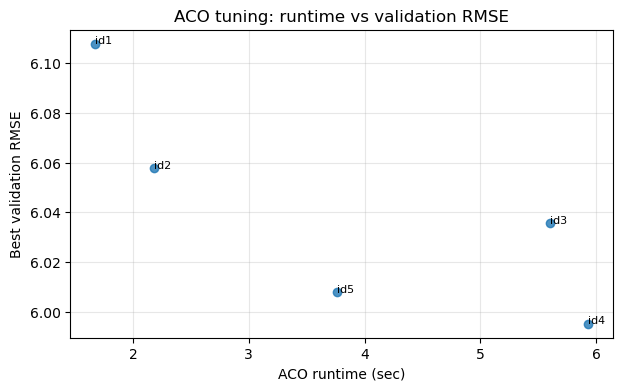

In [99]:
plt.figure(figsize=(7, 4))
plt.scatter(aco_tuning_df["runtime_sec"], aco_tuning_df["best_val_rmse"], alpha=0.8)

for _, row in aco_tuning_df.iterrows():
    plt.annotate(
        f"id{int(row['config_id'])}",
        (row["runtime_sec"], row["best_val_rmse"]),
        fontsize=8
    )

plt.xlabel("ACO runtime (sec)")
plt.ylabel("Best validation RMSE")
plt.title("ACO tuning: runtime vs validation RMSE")
plt.grid(alpha=0.3)
plt.show()

## Test Algorithms on Feature Subset

In [100]:
# Compare GD vs SA vs GA vs Linear Regression (Baseline) on the FIXED best subset

Xtr_subset = X_train[:, best_idx]
Xva_subset = X_tune[:, best_idx]
Xte_subset = X_test[:, best_idx]

# Define grids for parameter tuning
gd_grid = [
    GDConfig(lr=0.01, steps=3000, l2=0.0, tol=1e-8),
    GDConfig(lr=0.05, steps=3000, l2=0.0, tol=1e-8),
    GDConfig(lr=0.01, steps=6000, l2=0.0, tol=1e-8),
    GDConfig(lr=0.05, steps=6000, l2=0.0, tol=1e-8),   
    GDConfig(lr=0.01, steps=10000, l2=0.0, tol=1e-8),
    GDConfig(lr=0.05, steps=10000, l2=0.0, tol=1e-8),
]

sa_grid = [
    SAConfig(steps=6000, T0=0.5, alpha=0.995, step_sigma=0.03, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=6000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),  
    SAConfig(steps=10000, T0=2.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
    SAConfig(steps=10000, T0=1.0, alpha=0.999, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED),
]

ga_grid = [
    GAConfig(pop_size=50,  generations=150, elite=4, mutation_rate=0.2, mutation_sigma=0.10, init_sigma=0.10, seed=RANDOM_SEED),
    GAConfig(pop_size=100, generations=250, elite=6, mutation_rate=0.3, mutation_sigma=0.10, init_sigma=0.10, seed=RANDOM_SEED),
    GAConfig(pop_size=150, generations=250, elite=6, mutation_rate=0.3, mutation_sigma=0.10, init_sigma=0.10, seed=RANDOM_SEED),
    GAConfig(pop_size=100, generations=400, elite=6, mutation_rate=0.3, mutation_sigma=0.10, init_sigma=0.10, seed=RANDOM_SEED), 
    GAConfig(pop_size=100, generations=250, elite=6, mutation_rate=0.5, mutation_sigma=0.15, init_sigma=0.10, seed=RANDOM_SEED),
]

tuning_rows = []

# LR baseline (only one config)
lr_res = evaluate_method_on_validation("LR", Xtr_subset, y_train, Xva_subset, y_tune, cfg=None)
tuning_rows.append({
    "method": "LR",
    "config_label": "default",
    "val_rmse": lr_res["val_rmse"],
    "runtime_sec": lr_res["runtime_sec"],
    "cfg_obj": None
})

# GD
for i, cfg in enumerate(gd_grid, start=1):
    res = evaluate_method_on_validation("GD", Xtr_subset, y_train, Xva_subset, y_tune, cfg=cfg)
    tuning_rows.append({
        "method": "GD",
        "config_label": f"gd_{i}",
        "val_rmse": res["val_rmse"],
        "runtime_sec": res["runtime_sec"],
        "cfg_obj": cfg
    })

# SA
for i, cfg in enumerate(sa_grid, start=1):
    res = evaluate_method_on_validation("SA", Xtr_subset, y_train, Xva_subset, y_tune, cfg=cfg)
    tuning_rows.append({
        "method": "SA",
        "config_label": f"sa_{i}",
        "val_rmse": res["val_rmse"],
        "runtime_sec": res["runtime_sec"],
        "cfg_obj": cfg
    })

# GA
for i, cfg in enumerate(ga_grid, start=1):
    res = evaluate_method_on_validation("GA", Xtr_subset, y_train, Xva_subset, y_tune, cfg=cfg)
    tuning_rows.append({
        "method": "GA",
        "config_label": f"ga_{i}",
        "val_rmse": res["val_rmse"],
        "runtime_sec": res["runtime_sec"],
        "cfg_obj": cfg
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values(["method", "val_rmse"]).reset_index(drop=True)
tuning_df[["method", "config_label", "val_rmse", "runtime_sec"]]

best_cfg_by_method = {}

for method in ["GD", "SA", "GA"]:
    row = tuning_df[tuning_df["method"] == method].sort_values("val_rmse").iloc[0]
    best_cfg_by_method[method] = row["cfg_obj"]

print("Best GD config:", best_cfg_by_method["GD"])
print("Best SA config:", best_cfg_by_method["SA"])
print("Best GA config:", best_cfg_by_method["GA"])



Best GD config: GDConfig(lr=0.05, steps=10000, l2=0.0, tol=1e-08)
Best SA config: SAConfig(steps=10000, T0=2.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=42)
Best GA config: GAConfig(pop_size=100, generations=400, elite=6, tournament_k=3, crossover_rate=0.9, mutation_rate=0.3, mutation_sigma=0.1, init_sigma=0.1, l2=0.0, seed=42)


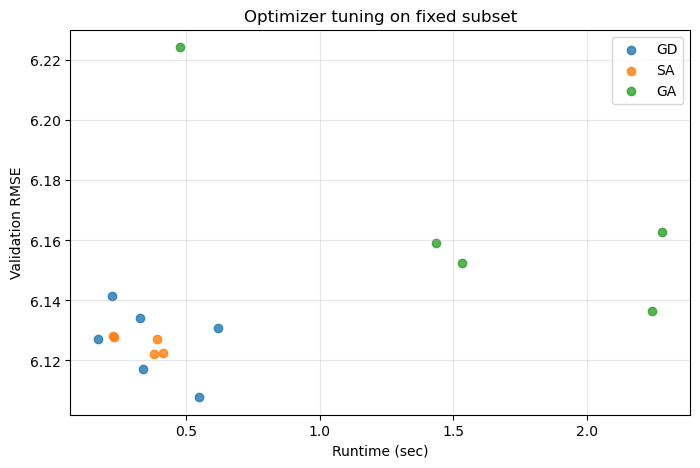

In [101]:
plt.figure(figsize=(8, 5))

for method in ["GD", "SA", "GA"]:
    sub = tuning_df[tuning_df["method"] == method]
    plt.scatter(sub["runtime_sec"], sub["val_rmse"], alpha=0.8, label=method)

plt.xlabel("Runtime (sec)")
plt.ylabel("Validation RMSE")
plt.title("Optimizer tuning on fixed subset")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [102]:
# For refitting we use train + selection + tuning data (all data except test)
Xtr_refit = np.vstack([X_train, X_sel, X_tune])[:, best_idx]
y_tr_refit = np.hstack([y_train, y_sel, y_tune])
Xte_subset = X_test[:, best_idx]          

subset_eval = {
    "preds": {},
    "weights": {},
    "histories": {},
    "runtimes": {},
    "metrics": {}
}

# LR
start = time.time()
lr_subset = LinearRegression()
lr_subset.fit(Xtr_refit, y_tr_refit)
subset_eval["runtimes"]["LR"] = time.time() - start

subset_eval["preds"]["LR"] = lr_subset.predict(Xte_subset)
subset_eval["weights"]["LR"] = lr_subset.coef_
subset_eval["histories"]["LR"] = None

# GD
start = time.time()
w_gd_subset, hist_gd_subset = fit_gd(Xtr_refit, y_tr_refit, best_cfg_by_method["GD"])
subset_eval["runtimes"]["GD"] = time.time() - start

subset_eval["preds"]["GD"] = add_bias(Xte_subset) @ w_gd_subset
subset_eval["weights"]["GD"] = w_gd_subset
subset_eval["histories"]["GD"] = hist_gd_subset

# SA
start = time.time()
w_sa_subset, hist_sa_subset = fit_sa(Xtr_refit, y_tr_refit, best_cfg_by_method["SA"])
subset_eval["runtimes"]["SA"] = time.time() - start

subset_eval["preds"]["SA"] = add_bias(Xte_subset) @ w_sa_subset
subset_eval["weights"]["SA"] = w_sa_subset
subset_eval["histories"]["SA"] = hist_sa_subset

# GA
start = time.time()
w_ga_subset, hist_ga_subset = fit_ga(Xtr_refit, y_tr_refit, best_cfg_by_method["GA"])
subset_eval["runtimes"]["GA"] = time.time() - start

subset_eval["preds"]["GA"] = add_bias(Xte_subset) @ w_ga_subset
subset_eval["weights"]["GA"] = w_ga_subset
subset_eval["histories"]["GA"] = hist_ga_subset

# Metrics
for method, pred in subset_eval["preds"].items():
    subset_eval["metrics"][method] = {
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        "test_mae": float(mean_absolute_error(y_test, pred)),
        "test_r2": float(r2_score(y_test, pred)),
        "runtime_sec": float(subset_eval["runtimes"][method]),
        "subset_size": int(len(best_subset)),
    }

subset_rows = []
for method in subset_eval["preds"].keys():
    row = {"method": method}
    row.update(subset_eval["metrics"][method])
    subset_rows.append(row)

subset_results = pd.DataFrame(subset_rows).sort_values("test_rmse").reset_index(drop=True)

subset_eval["results_df"] = subset_results
subset_results

,method,test_rmse,test_mae,test_r2,runtime_sec,subset_size
0,GA,6.229280,3.932222,0.378468,2.563058,12
1,LR,6.238200,4.086105,0.376687,0.002001,12
2,GD,6.300782,4.076115,0.364118,0.759979,12
3,SA,6.311350,4.065644,0.361983,0.473295,12


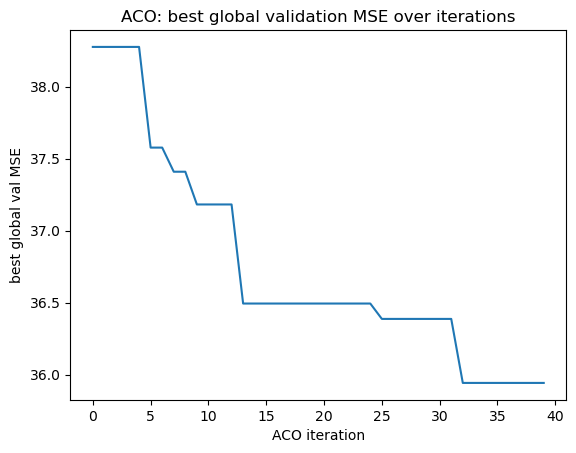

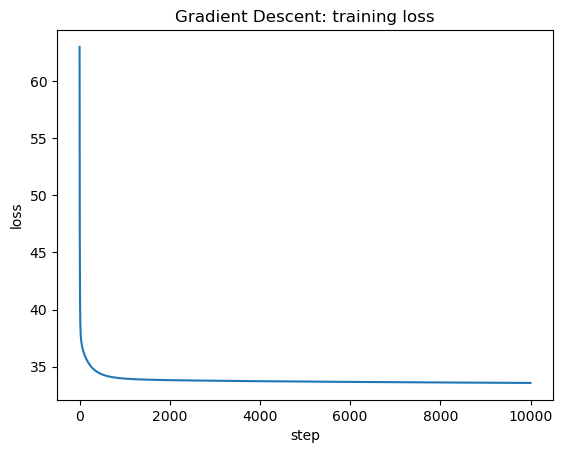

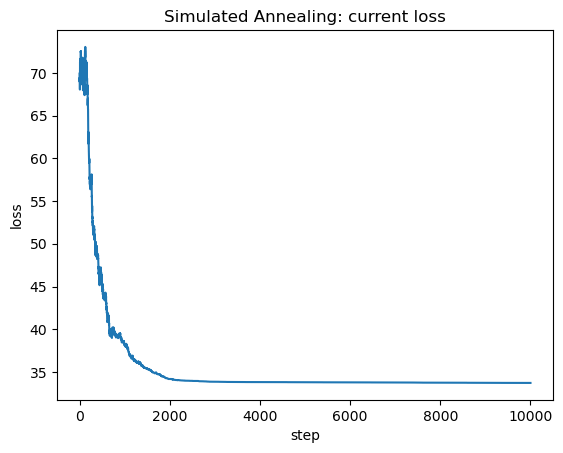

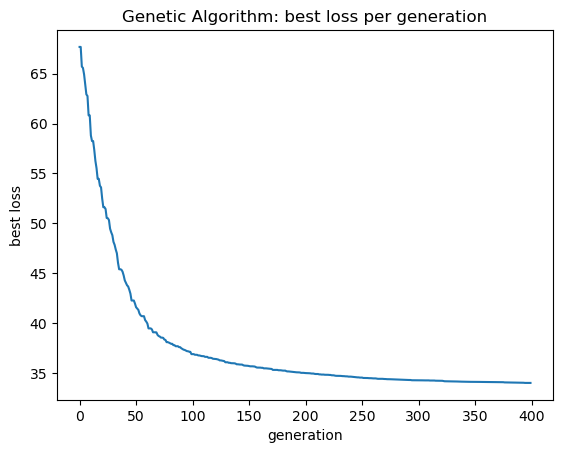

In [103]:
plt.figure()
plt.plot(aco_out["trace"]["best_global_mse"].to_numpy())
plt.title("ACO: best global validation MSE over iterations")
plt.xlabel("ACO iteration")
plt.ylabel("best global val MSE")
plt.show()

plt.figure()
plt.plot(subset_eval["histories"]["GD"])
plt.title("Gradient Descent: training loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(subset_eval["histories"]["SA"])
plt.title("Simulated Annealing: current loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(subset_eval["histories"]["GA"])
plt.title("Genetic Algorithm: best loss per generation")
plt.xlabel("generation")
plt.ylabel("best loss")
plt.show()

In [104]:
def plot_prediction_diagnostics(y_true, y_pred, model_name, bins=40):
    resid = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1) Predicted vs actual
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    axes[0].scatter(y_true, y_pred, alpha=0.4)
    axes[0].plot([lo, hi], [lo, hi], linestyle="--")
    axes[0].set_xlabel("Actual precipitation")
    axes[0].set_ylabel("Predicted precipitation")
    axes[0].set_title(f"{model_name}: predicted vs actual")
    axes[0].grid(alpha=0.3)

    # 2) Residual histogram
    axes[1].hist(resid, bins=bins)
    axes[1].set_xlabel("Residual (actual - predicted)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"{model_name}: residual distribution")
    axes[1].grid(alpha=0.3)

    # 3) Residuals vs fitted
    axes[2].scatter(y_pred, resid, alpha=0.4)
    axes[2].axhline(0, linestyle="--")
    axes[2].set_xlabel("Predicted precipitation")
    axes[2].set_ylabel("Residual")
    axes[2].set_title(f"{model_name}: residuals vs fitted")
    axes[2].grid(alpha=0.3)

    fig.suptitle(f"Prediction diagnostics — {model_name}", y=1.05)
    plt.tight_layout()
    plt.show()

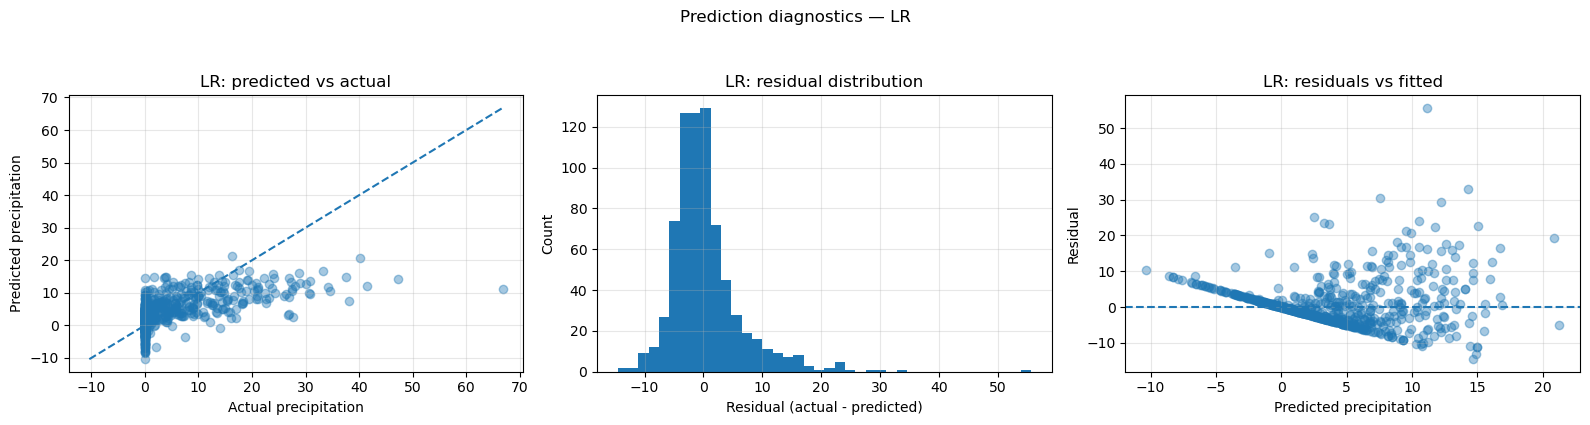

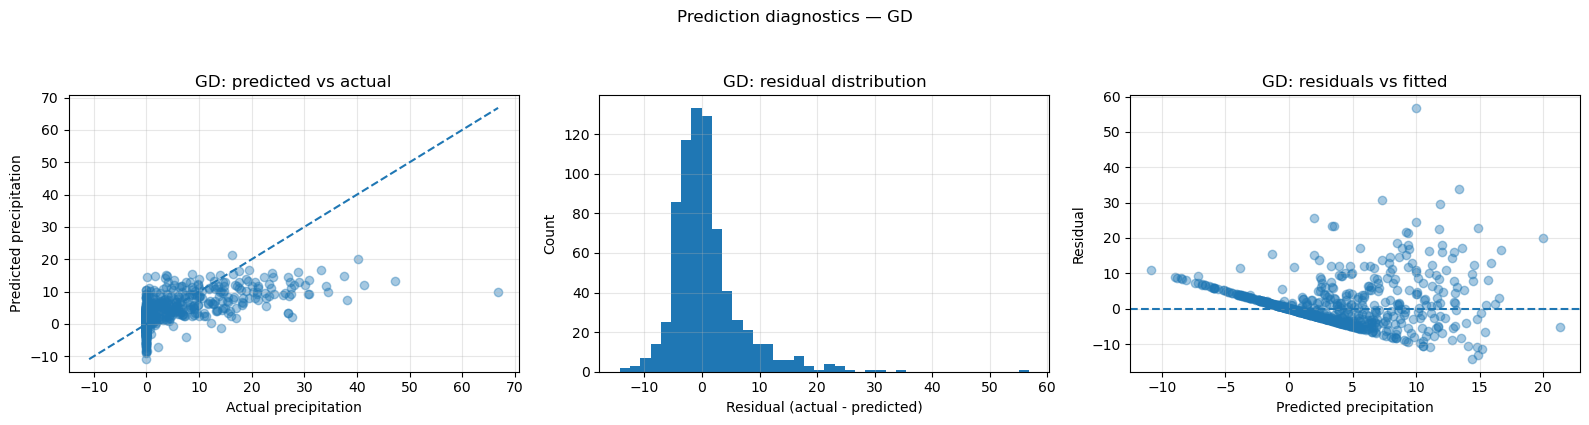

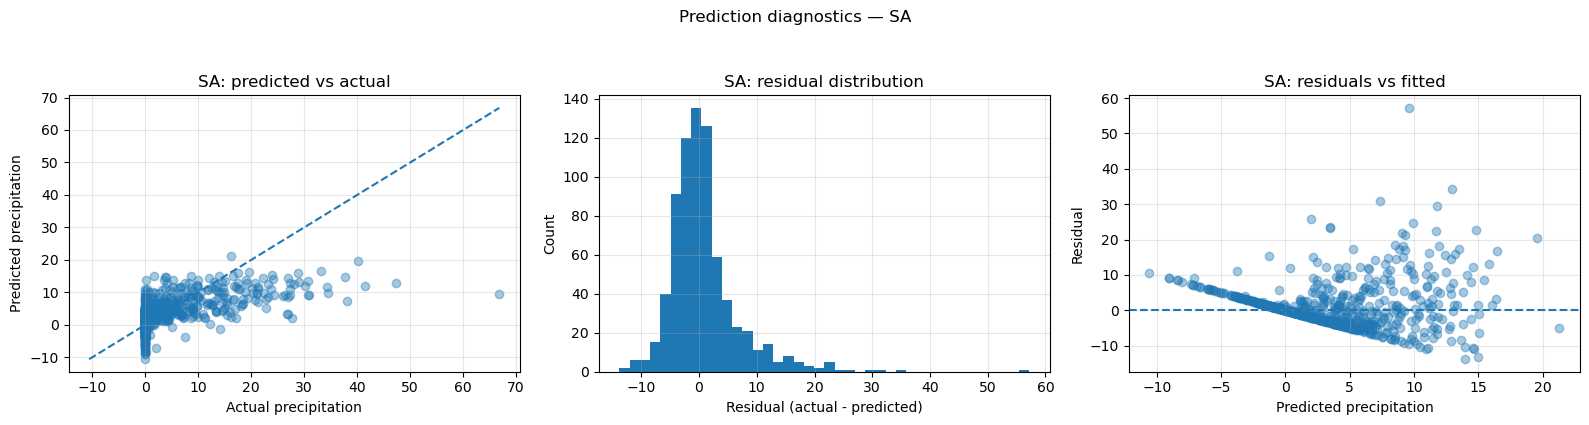

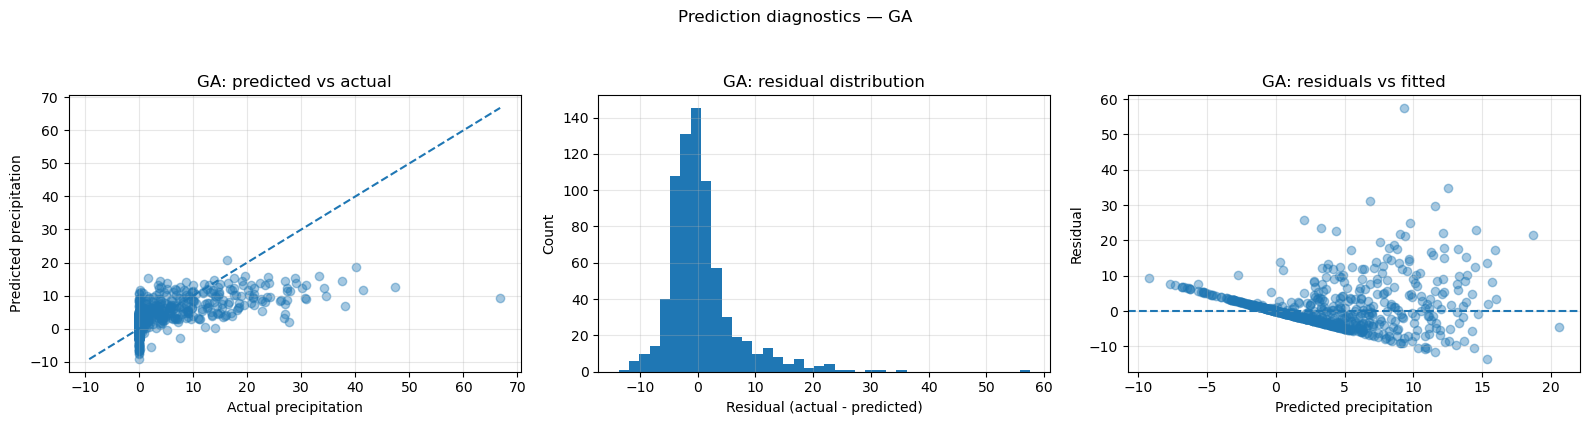

In [105]:
plot_prediction_diagnostics(y_test, subset_eval["preds"]["LR"], "LR")
plot_prediction_diagnostics(y_test, subset_eval["preds"]["GD"], "GD")
plot_prediction_diagnostics(y_test, subset_eval["preds"]["SA"], "SA")
plot_prediction_diagnostics(y_test, subset_eval["preds"]["GA"], "GA")

In [106]:
# Robustness Check: repeat the final optimizers on the fixed best subset
# using the locked best configs and refit on all non-test data

def run_optimizers_on_subset(seed: int) -> Dict:
    # Refit on all non-test data
    Xref = np.vstack([X_train, X_sel, X_tune])[:, best_idx]
    yref = np.hstack([y_train, y_sel, y_tune])
    Xte = X_test[:, best_idx]

    # ----- LR -----
    start = time.time()
    lr = LinearRegression()
    lr.fit(Xref, yref)
    runtime_lr = time.time() - start
    pred_lr = lr.predict(Xte)

    # ----- GD -----
    # GD is deterministic here, so this result will be identical across seeds
    gd_cfg = best_cfg_by_method["GD"]
    start = time.time()
    w_gd, _ = fit_gd(Xref, yref, gd_cfg)
    runtime_gd = time.time() - start
    pred_gd = add_bias(Xte) @ w_gd

    # ----- SA -----
    sa_cfg_base = best_cfg_by_method["SA"]
    sa_cfg = SAConfig(
        steps=sa_cfg_base.steps,
        T0=sa_cfg_base.T0,
        alpha=sa_cfg_base.alpha,
        step_sigma=sa_cfg_base.step_sigma,
        l2=sa_cfg_base.l2,
        seed=seed,
    )
    start = time.time()
    w_sa, _ = fit_sa(Xref, yref, sa_cfg)
    runtime_sa = time.time() - start
    pred_sa = add_bias(Xte) @ w_sa

    # ----- GA -----
    ga_cfg_base = best_cfg_by_method["GA"]
    ga_cfg = GAConfig(
        pop_size=ga_cfg_base.pop_size,
        generations=ga_cfg_base.generations,
        elite=ga_cfg_base.elite,
        mutation_rate=ga_cfg_base.mutation_rate,
        mutation_sigma=ga_cfg_base.mutation_sigma,
        init_sigma=ga_cfg_base.init_sigma,
        seed=seed,
    )
    start = time.time()
    w_ga, _ = fit_ga(Xref, yref, ga_cfg)
    runtime_ga = time.time() - start
    pred_ga = add_bias(Xte) @ w_ga

    return {
        "seed": seed,
        "rmse_lr": float(np.sqrt(mean_squared_error(y_test, pred_lr))),
        "rmse_gd": float(np.sqrt(mean_squared_error(y_test, pred_gd))),
        "rmse_sa": float(np.sqrt(mean_squared_error(y_test, pred_sa))),
        "rmse_ga": float(np.sqrt(mean_squared_error(y_test, pred_ga))),
        "mae_lr": float(mean_absolute_error(y_test, pred_lr)),
        "mae_gd": float(mean_absolute_error(y_test, pred_gd)),
        "mae_sa": float(mean_absolute_error(y_test, pred_sa)),
        "mae_ga": float(mean_absolute_error(y_test, pred_ga)),
        "r2_lr": float(r2_score(y_test, pred_lr)),
        "r2_gd": float(r2_score(y_test, pred_gd)),
        "r2_sa": float(r2_score(y_test, pred_sa)),
        "r2_ga": float(r2_score(y_test, pred_ga)),
        "runtime_lr": float(runtime_lr),
        "runtime_gd": float(runtime_gd),
        "runtime_sa": float(runtime_sa),
        "runtime_ga": float(runtime_ga),
    }

seeds = [1, 2, 3, 4, 5]
rob = pd.DataFrame([run_optimizers_on_subset(s) for s in seeds])
rob

,seed,rmse_lr,rmse_gd,rmse_sa,rmse_ga,mae_lr,mae_gd,mae_sa,mae_ga,r2_lr,r2_gd,r2_sa,r2_ga,runtime_lr,runtime_gd,runtime_sa,runtime_ga
0,1,6.2382,6.300782,6.333761,6.223712,4.086105,4.076115,4.099127,3.974283,0.376687,0.364118,0.357444,0.379579,0.002001,0.714170,0.436104,2.515529
1,2,6.2382,6.300782,6.305920,6.240831,4.086105,4.076115,4.070815,3.961194,0.376687,0.364118,0.363081,0.376161,0.000999,0.718382,0.432925,2.477611
2,3,6.2382,6.300782,6.317741,6.243856,4.086105,4.076115,4.057576,3.949147,0.376687,0.364118,0.360691,0.375556,0.001000,0.717592,0.452048,2.432326
3,4,6.2382,6.300782,6.318799,6.228118,4.086105,4.076115,4.050340,3.933479,0.376687,0.364118,0.360476,0.378700,0.001000,0.714170,0.451108,2.443352
4,5,6.2382,6.300782,6.315514,6.239939,4.086105,4.076115,4.072583,3.965215,0.376687,0.364118,0.361141,0.376340,0.002001,0.700002,0.430974,2.437592


In [107]:
# Robustness Check 2: repeat the FULL ACO + optimizers pipeline with different seeds

def run_full_pipeline(seed: int) -> Dict:
    gd_cfg_inner = GDConfig(lr=0.05, steps=1000, l2=0.0)

    aco_cfg = ACOConfig(
        n_ants=30,
        n_iters=15,
        evaporation=0.2,
        q=1.0,
        top_k=8,
        subset_min=2,
        subset_max=min(12, len(CANDIDATE_FEATURES)),
        seed=seed
    )

    # --- ACO feature selection
    start = time.time()
    out = aco_feature_selection(
        X_train, y_train, X_sel, y_sel,
        CANDIDATE_FEATURES, aco_cfg
    )
    runtime_aco = time.time() - start

    subset = out["best"]["features"]
    idx = np.array([CANDIDATE_FEATURES.index(f) for f in subset], dtype=int)

    Xtr = X_train[:, idx]
    Xte = X_test[:, idx]

    # LR
    start = time.time()
    lr = LinearRegression()
    lr.fit(Xtr, y_train)
    runtime_lr = time.time() - start
    pred_lr = lr.predict(Xte)
    
    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    mae_lr = mean_absolute_error(y_test, pred_lr)
    r2_lr = r2_score(y_test, pred_lr)


    # GD
    start = time.time()
    w_gd, _ = fit_gd(Xtr, y_train, GDConfig(lr=0.05, steps=2500, l2=0.0))
    runtime_gd = time.time() - start
    pred_gd = add_bias(Xte) @ w_gd

    rmse_gd = np.sqrt(mean_squared_error(y_test, pred_gd))
    mae_gd = mean_absolute_error(y_test, pred_gd)
    r2_gd = r2_score(y_test, pred_gd)

    # SA
    start = time.time()
    w_sa, _ = fit_sa(
        Xtr, y_train,
        SAConfig(
            steps=4000,
            T0=1.0,
            alpha=0.997,
            step_sigma=0.05,
            seed=seed
        )
    )
    runtime_sa = time.time() - start
    pred_sa = add_bias(Xte) @ w_sa

    rmse_sa = np.sqrt(mean_squared_error(y_test, pred_sa))
    mae_sa = mean_absolute_error(y_test, pred_sa)
    r2_sa = r2_score(y_test, pred_sa)

    # GA
    start = time.time()
    w_ga, _ = fit_ga(
        Xtr, y_train,
        GAConfig(
            pop_size=100,
            generations=250,
            elite=6,
            mutation_rate=0.3,
            mutation_sigma=0.1,
            init_sigma=0.1,
            seed=seed
        )
    )
    runtime_ga = time.time() - start
    pred_ga = add_bias(Xte) @ w_ga

    rmse_ga = np.sqrt(mean_squared_error(y_test, pred_ga))
    mae_ga = mean_absolute_error(y_test, pred_ga)
    r2_ga = r2_score(y_test, pred_ga)

    return {
        "seed": seed,
        "subset_size": len(subset),
        "subset": ",".join(subset),

        "aco_val_mse": out["best"]["mse"],
        "runtime_aco": runtime_aco,

        "rmse_lr": rmse_lr,
        "mae_lr": mae_lr,
        "r2_lr": r2_lr,
        "runtime_lr": runtime_lr,

        "rmse_gd": rmse_gd,
        "mae_gd": mae_gd,
        "r2_gd": r2_gd,
        "runtime_gd": runtime_gd,

        "rmse_sa": rmse_sa,
        "mae_sa": mae_sa,
        "r2_sa": r2_sa,
        "runtime_sa": runtime_sa,

        "rmse_ga": rmse_ga,
        "mae_ga": mae_ga,
        "r2_ga": r2_ga,
        "runtime_ga": runtime_ga,
    }

seeds = [1, 2, 3]
full_rob = pd.DataFrame([run_full_pipeline(s) for s in seeds])
full_rob

,seed,subset_size,subset,aco_val_mse,runtime_aco,rmse_lr,mae_lr,r2_lr,runtime_lr,rmse_gd,...,r2_gd,runtime_gd,rmse_sa,mae_sa,r2_sa,runtime_sa,rmse_ga,mae_ga,r2_ga,runtime_ga
0,1,12,"precip_lag1,soil_temp_5cm_mean_d,gust_ms_max_d...",36.844606,0.808501,6.566041,4.238210,0.309451,0.001,6.530937,...,0.316815,0.185754,6.527968,4.175220,0.317436,0.207603,6.372841,3.935262,0.349490,1.430624
1,2,12,"sealevel_pressure_d,heating_degree_days_d,doy_...",37.371721,0.819805,6.179409,3.841044,0.388380,0.001,6.179100,...,0.388442,0.183059,6.176313,3.852787,0.388993,0.167945,6.211491,3.859540,0.382013,1.392763
2,3,12,"temp5cm_max_d,gust_ms_max_d,wind_dir_mean_d,su...",36.201621,0.804591,6.384210,4.092946,0.347167,0.001,6.309324,...,0.362393,0.188045,6.219206,3.997613,0.380477,0.171041,6.196283,3.993298,0.385036,1.486944


## Comparison of ACO subset Model vs Full Model

In [108]:
Xtr_full = np.vstack([X_train, X_sel, X_tune])
ytr_full = np.hstack([y_train, y_sel, y_tune])
Xte_full = X_test

full_eval = {
    "preds": {},
    "weights": {},
    "histories": {},
    "runtimes": {},
    "metrics": {}
}

# LR FULL
start = time.time()
lr_full = LinearRegression()
lr_full.fit(Xtr_full, ytr_full)
full_eval["runtimes"]["LR"] = time.time() - start

full_eval["preds"]["LR"] = lr_full.predict(Xte_full)
full_eval["weights"]["LR"] = lr_full.coef_
full_eval["histories"]["LR"] = None

# GD FULL
start = time.time()
w_gd_full, hist_gd_full = fit_gd(Xtr_full, ytr_full, best_cfg_by_method["GD"])
full_eval["runtimes"]["GD"] = time.time() - start

full_eval["preds"]["GD"] = add_bias(Xte_full) @ w_gd_full
full_eval["weights"]["GD"] = w_gd_full
full_eval["histories"]["GD"] = hist_gd_full

# SA FULL
sa_cfg_full = SAConfig(
    steps=best_cfg_by_method["SA"].steps,
    T0=best_cfg_by_method["SA"].T0,
    alpha=best_cfg_by_method["SA"].alpha,
    step_sigma=best_cfg_by_method["SA"].step_sigma,
    l2=best_cfg_by_method["SA"].l2,
    seed=RANDOM_SEED,
)
start = time.time()
w_sa_full, hist_sa_full = fit_sa(Xtr_full, ytr_full, sa_cfg_full)
full_eval["runtimes"]["SA"] = time.time() - start

full_eval["preds"]["SA"] = add_bias(Xte_full) @ w_sa_full
full_eval["weights"]["SA"] = w_sa_full
full_eval["histories"]["SA"] = hist_sa_full

# GA FULL
ga_cfg_full = GAConfig(
    pop_size=best_cfg_by_method["GA"].pop_size,
    generations=best_cfg_by_method["GA"].generations,
    elite=best_cfg_by_method["GA"].elite,
    tournament_k=best_cfg_by_method["GA"].tournament_k,
    crossover_rate=best_cfg_by_method["GA"].crossover_rate,
    mutation_rate=best_cfg_by_method["GA"].mutation_rate,
    mutation_sigma=best_cfg_by_method["GA"].mutation_sigma,
    init_sigma=best_cfg_by_method["GA"].init_sigma,
    l2=best_cfg_by_method["GA"].l2,
    seed=RANDOM_SEED,
)
start = time.time()
w_ga_full, hist_ga_full = fit_ga(Xtr_full, ytr_full, ga_cfg_full)
full_eval["runtimes"]["GA"] = time.time() - start

full_eval["preds"]["GA"] = add_bias(Xte_full) @ w_ga_full
full_eval["weights"]["GA"] = w_ga_full
full_eval["histories"]["GA"] = hist_ga_full

# Metrics
for method, pred in full_eval["preds"].items():
    full_eval["metrics"][method] = {
        "rmse_full": float(np.sqrt(mean_squared_error(y_test, pred))),
        "mae_full": float(mean_absolute_error(y_test, pred)),
        "r2_full": float(r2_score(y_test, pred)),
        "runtime_full": float(full_eval["runtimes"][method]),
    }

full_results = (
    pd.DataFrame(full_eval["metrics"])
    .T
    .reset_index()
    .rename(columns={"index": "method"})
    .sort_values("rmse_full")
    .reset_index(drop=True)
)

full_eval["results_df"] = full_results
full_results

,method,rmse_full,mae_full,r2_full,runtime_full
0,SA,6.126855,3.997976,0.398740,0.554830
1,GA,6.127719,3.994235,0.398570,2.955569
2,LR,6.177028,4.023685,0.388852,0.002999
3,GD,6.194456,4.070362,0.385398,1.137918


In [109]:
comparison = subset_eval["results_df"].merge(full_eval["results_df"], on="method")
comparison

,method,test_rmse,test_mae,test_r2,runtime_sec,subset_size,rmse_full,mae_full,r2_full,runtime_full
0,GA,6.229280,3.932222,0.378468,2.563058,12,6.127719,3.994235,0.398570,2.955569
1,LR,6.238200,4.086105,0.376687,0.002001,12,6.177028,4.023685,0.388852,0.002999
2,GD,6.300782,4.076115,0.364118,0.759979,12,6.194456,4.070362,0.385398,1.137918
3,SA,6.311350,4.065644,0.361983,0.473295,12,6.126855,3.997976,0.398740,0.554830


In [110]:
subset_results = subset_eval["results_df"].copy()

best_model_name = subset_results.iloc[0]["method"]
best_pred = subset_eval["preds"][best_model_name]

print("Best model for diagnostic plots:", best_model_name)
print("Best test RMSE:", subset_eval["metrics"][best_model_name]["test_rmse"])

Best model for diagnostic plots: GA
Best test RMSE: 6.229279773526788


## Result Diagnostics

In [111]:
subset_results = subset_eval["results_df"].copy()

best_model_name = subset_results.iloc[0]["method"]
best_pred = subset_eval["preds"][best_model_name]

print("Best model for diagnostic plots:", best_model_name)
print("Best test RMSE:", subset_eval["metrics"][best_model_name]["test_rmse"])

Best model for diagnostic plots: GA
Best test RMSE: 6.229279773526788


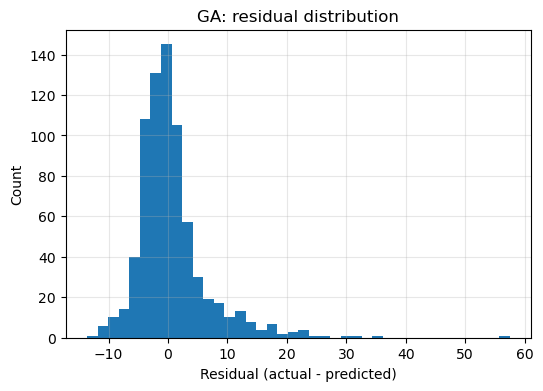

In [112]:
resid = y_test - best_pred

plt.figure(figsize=(6, 4))
plt.hist(resid, bins=40)
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Count")
plt.title(f"{best_model_name}: residual distribution")
plt.grid(alpha=0.3)
plt.show()

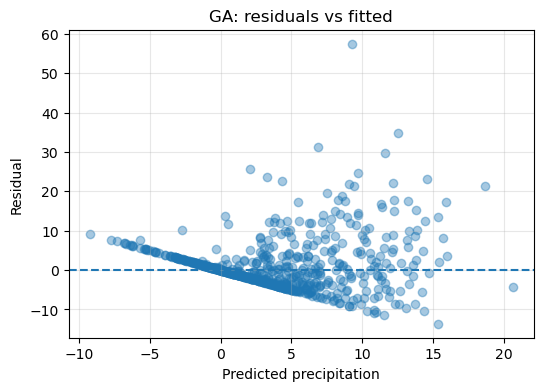

In [113]:
plt.figure(figsize=(6, 4))
plt.scatter(best_pred, resid, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted precipitation")
plt.ylabel("Residual")
plt.title(f"{best_model_name}: residuals vs fitted")
plt.grid(alpha=0.3)
plt.show()

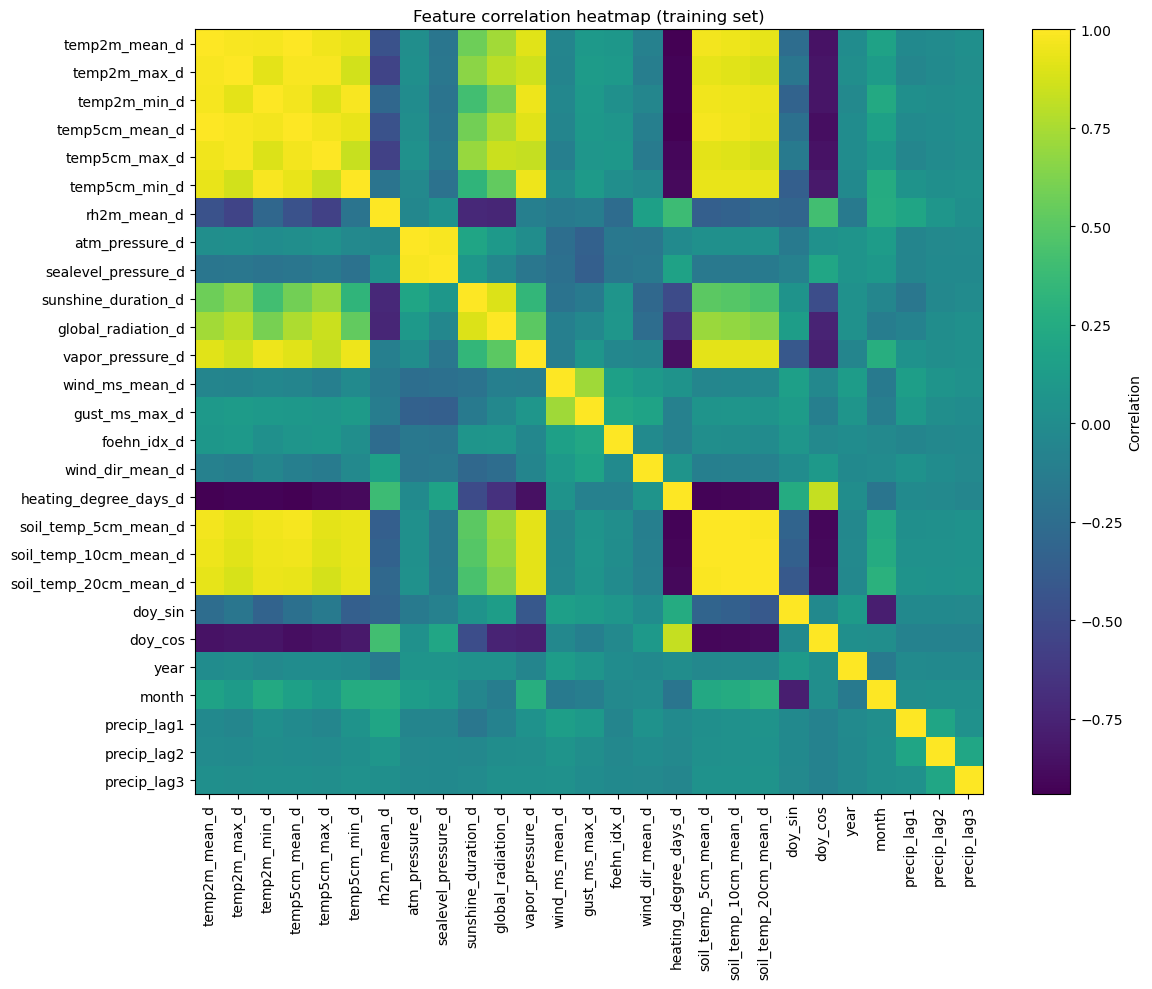

In [114]:
corr_df = pd.DataFrame(X_train, columns=CANDIDATE_FEATURES)
corr = corr_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(CANDIDATE_FEATURES)), CANDIDATE_FEATURES, rotation=90)
plt.yticks(range(len(CANDIDATE_FEATURES)), CANDIDATE_FEATURES)
plt.title("Feature correlation heatmap (training set)")
plt.tight_layout()
plt.show()

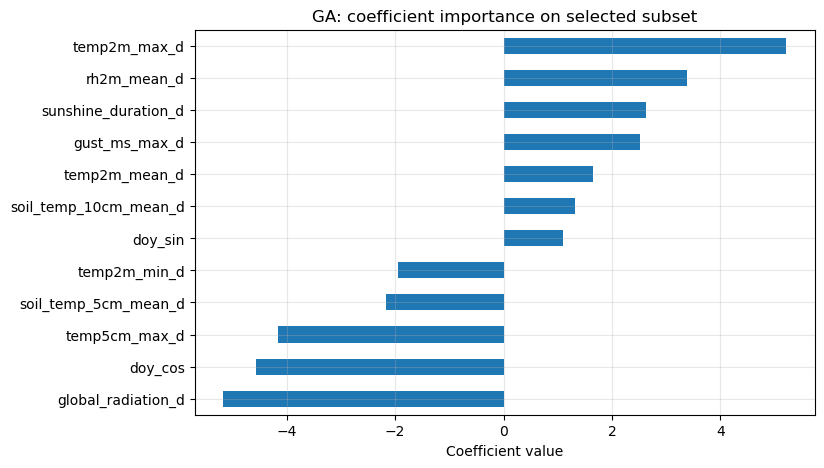

In [115]:
if best_model_name == "LR":
    coef_values = subset_eval["weights"]["LR"]
else:
    coef_values = subset_eval["weights"][best_model_name][1:]  # drop bias

coef_series = pd.Series(coef_values, index=best_subset)
coef_series = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 5))
coef_series.iloc[:12].sort_values().plot(kind="barh")
plt.xlabel("Coefficient value")
plt.title(f"{best_model_name}: coefficient importance on selected subset")
plt.grid(alpha=0.3)
plt.show()